# Granger Causality Analysis - Infant EEG Dataset

This notebook implements a minimal Granger causality analysis pipeline following the simplified roadmap.

## Step 1: Load Data

Load EDF file with MNE and extract EEG channels and sampling rate.

In [1]:
# Import required libraries
import mne
import numpy as np
import os
from pathlib import Path

# Suppress MNE warnings for cleaner output
mne.set_log_level('WARNING')

In [2]:
# Set dataset path
dataset_path = Path('/home/alookaladdoo/DPCN-Project/Dataset')

# Get list of all subjects
subjects = sorted([d for d in os.listdir(dataset_path) if d.startswith('sub-NORB')])
print(f"Found {len(subjects)} subjects")

Found 103 subjects


In [4]:
# Function to find EDF files for a subject
def find_edf_files(subject_id):
    """Find all EDF files for a given subject."""
    subject_path = dataset_path / subject_id
    edf_files = []
    
    if subject_path.exists():
        # Search for EDF files in subject directory
        edf_files = list(subject_path.rglob('*.edf'))
    
    return edf_files

# Test with first subject
test_subject = subjects[41]
edf_files = find_edf_files(test_subject)
print(f"\n{test_subject}:")
print(f"  Found {len(edf_files)} EDF file(s)")
for edf in edf_files:
    print(f"  - {edf.name}")


sub-NORB00042:
  Found 1 EDF file(s)
  - sub-NORB00042_ses-1_task-EEG_eeg.edf


In [5]:
# Function to load EDF file
def load_edf_data(edf_path):
    """
    Load EDF file with MNE and extract EEG channels.
    
    Parameters:
    -----------
    edf_path : str or Path
        Path to the EDF file
        
    Returns:
    --------
    raw : mne.io.Raw
        Raw EEG data
    """
    # Load the EDF file
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    
    # Get info
    n_channels = len(raw.ch_names)
    sampling_rate = raw.info['sfreq']
    duration = raw.times[-1]
    
    print(f"\nLoaded: {Path(edf_path).name}")
    print(f"  Channels: {n_channels}")
    print(f"  Sampling rate: {sampling_rate} Hz")
    print(f"  Duration: {duration:.2f} seconds")
    print(f"  Channel names: {raw.ch_names}")
    
    return raw

# Load the first EDF file as a test
if edf_files:
    raw = load_edf_data(edf_files[0])
else:
    print("No EDF files found for testing")


Loaded: sub-NORB00042_ses-1_task-EEG_eeg.edf
  Channels: 24
  Sampling rate: 200.0 Hz
  Duration: 1187.99 seconds
  Channel names: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ', 'Pg1', 'Pg2', '25+', '26+', '27+']


/tmp/ipykernel_45995/3190308585.py:17: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
/tmp/ipykernel_45995/3190308585.py:17: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


In [6]:
# Extract EEG data as numpy array
if 'raw' in locals():
    # Get the data
    data = raw.get_data()  # Shape: (n_channels, n_timepoints)
    sampling_rate = raw.info['sfreq']
    channel_names = raw.ch_names
    
    print(f"\nExtracted data shape: {data.shape}")
    print(f"  Number of channels: {data.shape[0]}")
    print(f"  Number of timepoints: {data.shape[1]}")
    print(f"  Duration: {data.shape[1] / sampling_rate:.2f} seconds")


Extracted data shape: (24, 237600)
  Number of channels: 24
  Number of timepoints: 237600
  Duration: 1188.00 seconds


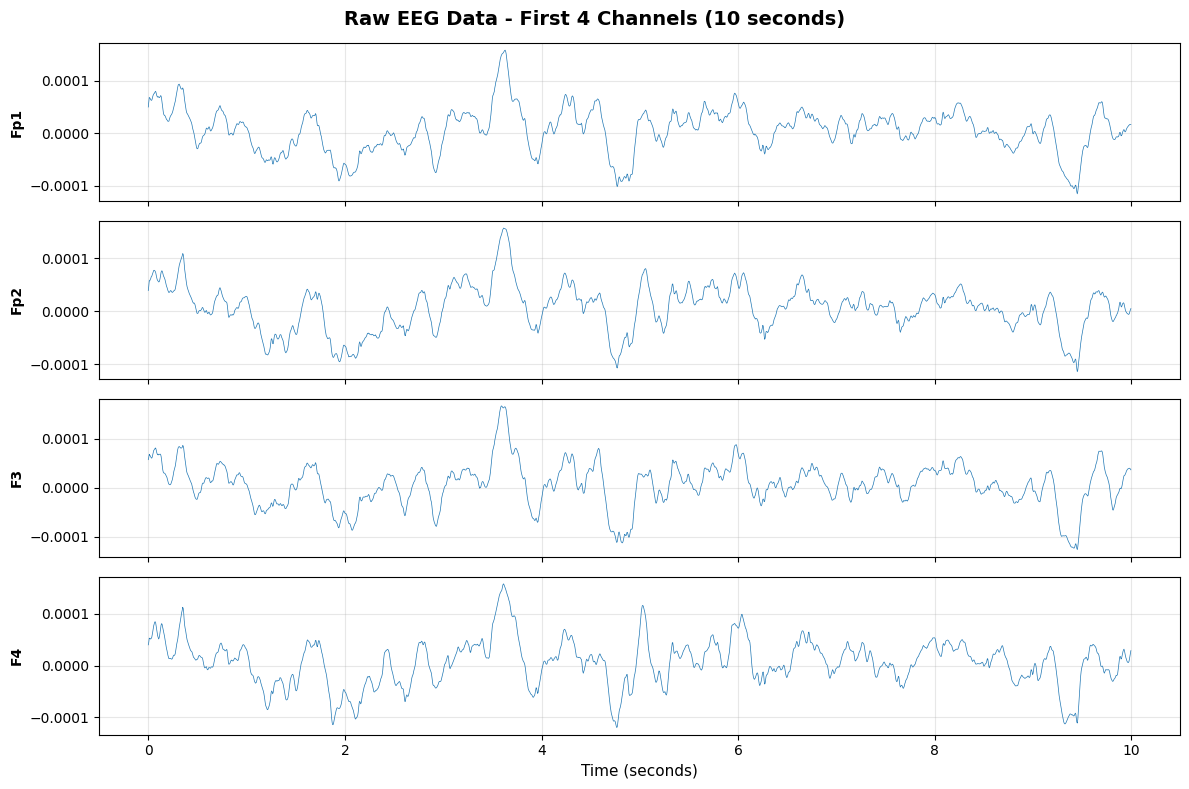

Displayed raw data for first 4 channels


In [7]:
# Plot raw data - first few channels
import matplotlib.pyplot as plt

if 'raw' in locals():
    # Plot first 10 seconds of first 4 channels
    fig, axes = plt.subplots(4, 1, figsize=(12, 8))
    fig.suptitle('Raw EEG Data - First 4 Channels (10 seconds)', fontsize=14, fontweight='bold')
    
    duration = 10  # seconds
    n_samples = int(duration * raw.info['sfreq'])
    time = np.arange(n_samples) / raw.info['sfreq']
    
    for i in range(min(4, len(raw.ch_names))):
        axes[i].plot(time, data[i, :n_samples], linewidth=0.5)
        axes[i].set_ylabel(raw.ch_names[i], fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        if i < 3:
            axes[i].set_xticklabels([])
    
    axes[-1].set_xlabel('Time (seconds)', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    print(f"Displayed raw data for first 4 channels")

## Step 2: Preprocess

Apply bandpass filter (0.5-30 Hz) and segment data into 10-second windows.

In [8]:
# Detect and remove bad channels
def detect_bad_channels(raw, flat_threshold=1e-12, noise_threshold=1e-3):
    """
    Detect bad channels (flat or extremely noisy).
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    flat_threshold : float
        Threshold for flat channels (std < threshold)
    noise_threshold : float
        Threshold for noisy channels (std > threshold)
        
    Returns:
    --------
    bad_channels : list
        List of bad channel names
    """
    data = raw.get_data()
    channel_names = raw.ch_names
    bad_channels = []
    
    print("\nChannel Quality Check:")
    print("-" * 60)
    
    for i, ch_name in enumerate(channel_names):
        ch_data = data[i, :]
        ch_std = np.std(ch_data)
        ch_mean = np.mean(ch_data)
        ch_range = np.max(ch_data) - np.min(ch_data)
        
        is_bad = False
        reason = []
        
        # Check if flat
        if ch_std < flat_threshold:
            is_bad = True
            reason.append("FLAT")
        
        # Check if too noisy
        if ch_std > noise_threshold:
            is_bad = True
            reason.append("NOISY")
        
        # Check if constant value
        if ch_range == 0:
            is_bad = True
            reason.append("CONSTANT")
        
        # Check for common reference/ground channels (PG1, PG2, etc.)
        if ch_name.upper() in ['PG1', 'PG2', 'REF', 'GND', 'GROUND', '25+', '26+', '27+']:
            is_bad = True
            reason.append("REFERENCE/GROUND")
        
        status = "BAD" if is_bad else "OK"
        reason_str = ", ".join(reason) if reason else ""
        
        print(f"  {ch_name:15s} | std={ch_std:.2e} | mean={ch_mean:.2e} | {status:4s} {reason_str}")
        
        if is_bad:
            bad_channels.append(ch_name)
    
    print("-" * 60)
    print(f"\nFound {len(bad_channels)} bad channel(s): {bad_channels}")
    
    return bad_channels

# Detect bad channels
if 'raw' in locals():
    bad_channels = detect_bad_channels(raw)
    
    # Remove bad channels if any found
    if bad_channels:
        raw_clean = raw.copy()
        raw_clean.drop_channels(bad_channels)
        print(f"\nRemoved {len(bad_channels)} bad channel(s)")
        print(f"Remaining channels ({len(raw_clean.ch_names)}): {raw_clean.ch_names}")
    else:
        raw_clean = raw.copy()
        print("\nNo bad channels detected. Proceeding with all channels.")
else:
    print("Error: 'raw' data not found. Please run Step 1 first.")


Channel Quality Check:
------------------------------------------------------------
  Fp1             | std=2.81e-05 | mean=7.39e-06 | OK   
  Fp2             | std=3.05e-05 | mean=6.16e-06 | OK   
  F3              | std=3.21e-05 | mean=6.82e-06 | OK   
  F4              | std=3.30e-05 | mean=6.15e-06 | OK   
  C3              | std=3.35e-05 | mean=6.99e-06 | OK   
  C4              | std=3.27e-05 | mean=6.65e-06 | OK   
  P3              | std=3.22e-05 | mean=6.49e-06 | OK   
  P4              | std=3.13e-05 | mean=6.92e-06 | OK   
  O1              | std=3.10e-05 | mean=5.76e-06 | OK   
  O2              | std=3.40e-05 | mean=7.01e-06 | OK   
  F7              | std=2.48e-05 | mean=5.78e-06 | OK   
  F8              | std=2.84e-05 | mean=7.11e-06 | OK   
  T3              | std=2.33e-05 | mean=5.77e-06 | OK   
  T4              | std=2.60e-05 | mean=7.46e-06 | OK   
  T5              | std=2.90e-05 | mean=5.88e-06 | OK   
  T6              | std=2.87e-05 | mean=6.37e-06 | OK   
  F

In [9]:
# Apply bandpass filter (0.5-30 Hz)
if 'raw_clean' in locals():
    # Create a copy to preserve original data
    raw_filtered = raw_clean.copy()
    
    # Apply bandpass filter
    raw_filtered.filter(l_freq=0.5, h_freq=30.0, fir_design='firwin', verbose=False)
    
    print("\nApplied bandpass filter: 0.5-30 Hz")
    print(f"  Filter type: FIR (firwin)")
    print(f"  Data shape after filtering: {raw_filtered.get_data().shape}")
    print(f"  Channels in filtered data: {len(raw_filtered.ch_names)}")
else:
    print("Error: 'raw_clean' data not found. Please run bad channel detection first.")


Applied bandpass filter: 0.5-30 Hz
  Filter type: FIR (firwin)
  Data shape after filtering: (19, 237600)
  Channels in filtered data: 19


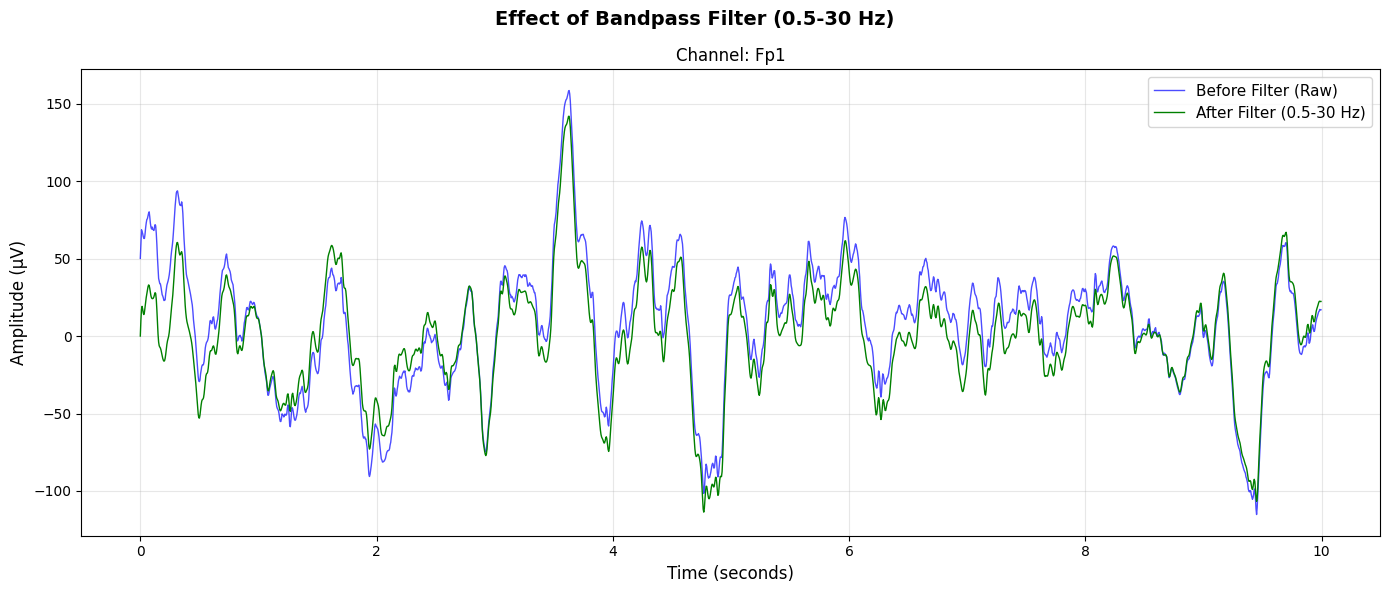

Filter comparison complete for channel: Fp1


In [10]:
# Compare raw vs filtered data
if 'raw_filtered' in locals() and 'raw_clean' in locals():
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    fig.suptitle('Effect of Bandpass Filter (0.5-30 Hz)', fontsize=14, fontweight='bold')
    
    # Get data for first channel
    ch_idx = 0
    duration = 10  # seconds
    n_samples = int(duration * raw_clean.info['sfreq'])
    time = np.arange(n_samples) / raw_clean.info['sfreq']
    
    # Convert to microvolts (assuming data is in volts)
    raw_data = raw_clean.get_data()[ch_idx, :n_samples] * 1e6  # Convert to µV
    filtered_data = raw_filtered.get_data()[ch_idx, :n_samples] * 1e6  # Convert to µV
    
    # Plot both on same graph
    ax.plot(time, raw_data, linewidth=1, color='blue', alpha=0.7, label='Before Filter (Raw)')
    ax.plot(time, filtered_data, linewidth=1, color='green', label='After Filter (0.5-30 Hz)')
    
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('Amplitude (µV)', fontsize=12)
    ax.set_title(f'Channel: {raw_clean.ch_names[ch_idx]}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Filter comparison complete for channel: {raw_clean.ch_names[ch_idx]}")

In [ ]:
# Segment data into 10-second windows
def segment_data(raw, window_length=10.0, overlap=0.0):
    """
    Segment continuous EEG data into fixed-length windows.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Filtered raw EEG data
    window_length : float
        Length of each window in seconds (default: 10.0)
    overlap : float
        Overlap between windows as fraction (0.0 to 1.0, default: 0.0)
        
    Returns:
    --------
    segments : list of numpy arrays
        List of data segments, each with shape (n_channels, n_samples_per_window)
    """
    sfreq = raw.info['sfreq']
    data = raw.get_data()
    n_channels, n_samples = data.shape
    
    # Calculate window parameters
    samples_per_window = int(window_length * sfreq)
    step_size = int(samples_per_window * (1 - overlap))
    
    # Create segments
    segments = []
    start = 0
    
    while start + samples_per_window <= n_samples:
        segment = data[:, start:start + samples_per_window]
        segments.append(segment)
        start += step_size
    
    print(f"\nSegmented data into {len(segments)} windows")
    print(f"  Window length: {window_length} seconds")
    print(f"  Samples per window: {samples_per_window}")
    print(f"  Overlap: {overlap * 100}%")
    print(f"  Each segment shape: ({n_channels}, {samples_per_window})")
    
    return segments

# Apply segmentation
if 'raw_filtered' in locals():
    segments = segment_data(raw_filtered, window_length=10.0, overlap=0.5)
    # segments = segment_data(raw_filtered, window_length=10.0, overlap=0.0)
else:
    print("Error: 'raw_filtered' data not found. Please run filtering first.")


Segmented data into 118 windows
  Window length: 10.0 seconds
  Samples per window: 2000
  Overlap: 0.0%
  Each segment shape: (19, 2000)


In [12]:
# Normalize/Standardize segments for VAR model
def normalize_segments(segments):
    """
    Standardize each segment by z-scoring each channel.
    This ensures all channels have similar scales for VAR modeling.
    
    Parameters:
    -----------
    segments : list of numpy arrays
        List of data segments, each with shape (n_channels, n_samples)
        
    Returns:
    --------
    normalized_segments : list of numpy arrays
        Standardized segments
    """
    normalized_segments = []
    
    for segment in segments:
        # Z-score normalization: (x - mean) / std for each channel
        mean = segment.mean(axis=1, keepdims=True)
        std = segment.std(axis=1, keepdims=True)
        
        # Avoid division by zero for flat channels
        std[std == 0] = 1
        
        normalized_segment = (segment - mean) / std
        normalized_segments.append(normalized_segment)
    
    return normalized_segments

# Apply normalization
if 'segments' in locals() and len(segments) > 0:
    segments_normalized = normalize_segments(segments)
    
    print(f"\nNormalized {len(segments_normalized)} segments")
    print(f"  Original segment mean: {segments[0].mean():.2e}, std: {segments[0].std():.2e}")
    print(f"  Normalized segment mean: {segments_normalized[0].mean():.2e}, std: {segments_normalized[0].std():.2f}")
    print(f"\nSegments ready for VAR modeling!")
else:
    print("Error: No segments found.")


Normalized 118 segments
  Original segment mean: -1.59e-06, std: 3.85e-05
  Normalized segment mean: 3.18e-18, std: 1.00

Segments ready for VAR modeling!


## Step 3: Compute Granger Causality

Select model order using AIC, fit VAR model, and calculate GC values for all channel pairs.

In [13]:
# Import statsmodels for VAR model
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')  # Suppress convergence warnings

print("Statsmodels imported successfully for VAR modeling")

Statsmodels imported successfully for VAR modeling


In [58]:
# Select optimal model order using BIC
def select_model_order(segment, max_order=20):
    model = VAR(segment.T)
    bic_values = {}
    for order in range(1, max_order + 1):
        try:
            bic_values[order] = model.fit(order, verbose=False).bic
        except:
            continue
    return min(bic_values, key=bic_values.get) if bic_values else 1

# Test on first segment
if 'segments' in locals() and len(segments) > 0:
    optimal_order = select_model_order(segments[0], max_order=20)
    print(f"Optimal model order (BIC): {optimal_order}")
else:
    print("Error: No segments found.")

Optimal model order (BIC): 15


In [ ]:
# Fit VAR model on each window
def fit_var_models(segments, order):
    """Fit VAR model on each segment."""
    fitted_models = []
    n_segments = len(segments)
    print(f"Fitting VAR models for {n_segments} windows...")
    
    for idx, segment in enumerate(segments, 1):
        model = VAR(segment.T)
        fitted_models.append(model.fit(order, verbose=False))
        
        # Progress meter
        progress = (idx / n_segments) * 100
        print(f"  Progress: {idx}/{n_segments} ({progress:.1f}%)", end='\r')
    
    print()  # New line after progress
    return fitted_models

# Fit VAR models using optimal order
if 'segments_normalized' in locals() and 'optimal_order' in locals():
    var_models = fit_var_models(segments_normalized, optimal_order)
    # var_models = fit_var_models(segments_normalized, 2)  # Placeholder for optimal_order

    print(f"✓ Fitted {len(var_models)} VAR models with order {optimal_order}")
else:
    print("Error: Need normalized segments and optimal order.")

Fitting VAR models for 71 windows...
  Progress: 71/71 (100.0%)
✓ Fitted 71 VAR models with order 15
  Progress: 71/71 (100.0%)
✓ Fitted 71 VAR models with order 15


In [62]:
# Calculate Granger causality for all channel pairs
def compute_gc_matrix(var_model, n_channels):
    """Compute GC matrix from fitted VAR model."""
    gc_matrix = np.zeros((n_channels, n_channels))
    for i in range(n_channels):
        for j in range(n_channels):
            if i != j:
                gc_result = var_model.test_causality(i, j, kind='f')
                gc_matrix[j, i] = -np.log(gc_result.pvalue + 1e-10)  # -log(p-value)
    return gc_matrix

# Compute GC for each window
if 'var_models' in locals():
    n_channels = len(raw_filtered.ch_names)
    n_windows = len(var_models)
    gc_matrices = []
    
    print(f"Computing GC matrices for {n_windows} windows...")
    for window_idx, model in enumerate(var_models, 1):
        gc_matrix = compute_gc_matrix(model, n_channels)
        gc_matrices.append(gc_matrix)
        
        # Progress meter
        progress = (window_idx / n_windows) * 100
        print(f"  Progress: {window_idx}/{n_windows} ({progress:.1f}%)", end='\r')
    
    print(f"\n✓ Computed GC matrices for {len(gc_matrices)} windows")
    print(f"  GC matrix shape: {gc_matrices[0].shape}")
else:
    print("Error: No VAR models found.")

Computing GC matrices for 71 windows...
  Progress: 71/71 (100.0%)
✓ Computed GC matrices for 71 windows
  GC matrix shape: (19, 19)
  Progress: 71/71 (100.0%)
✓ Computed GC matrices for 71 windows
  GC matrix shape: (19, 19)


In [63]:
# Average GC across windows
if 'gc_matrices' in locals():
    gc_avg = np.mean(gc_matrices, axis=0)
    print(f"\nAveraged GC matrix shape: {gc_avg.shape}")
    print(f"  Mean GC value: {gc_avg.mean():.4f}")
    print(f"  Max GC value: {gc_avg.max():.4f}")
    print(f"\nGranger causality computation complete!")
else:
    print("Error: No GC matrices found.")


Averaged GC matrix shape: (19, 19)
  Mean GC value: 3.6947
  Max GC value: 15.2931

Granger causality computation complete!


## Step 4: Save Results

Save GC matrix as `.npy` file and create heatmap visualization.

In [64]:
# Save GC matrix
if 'gc_avg' in locals() and 'edf_files' in locals():
    # Create results directory
    results_dir = Path('/home/alookaladdoo/DPCN-Project/results')
    results_dir.mkdir(exist_ok=True)
    
    # Extract subject and session info from EDF filename
    edf_name = edf_files[0].stem  # e.g., 'sub-NORB00001_ses-01_task-rest_eeg'
    parts = edf_name.split('_')
    subject_id = parts[0]  # sub-NORB00001
    session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-01'
    
    # Save GC matrix
    output_file = results_dir / f"{subject_id}_{session_id}_gc_matrix.npy"
    np.save(output_file, gc_avg)
    print(f"✓ Saved GC matrix to: {output_file}")
    print(f"  Shape: {gc_avg.shape}")
else:
    print("Error: GC matrix or EDF files not found.")

✓ Saved GC matrix to: /home/alookaladdoo/DPCN-Project/results/sub-NORB00001_ses-1_gc_matrix.npy
  Shape: (19, 19)


✓ Saved heatmap to: /home/alookaladdoo/DPCN-Project/results/sub-NORB00001_ses-1_gc_heatmap.png
  Original range: [0.0000, 15.2931]
  Normalized range: [0.0, 1.0]


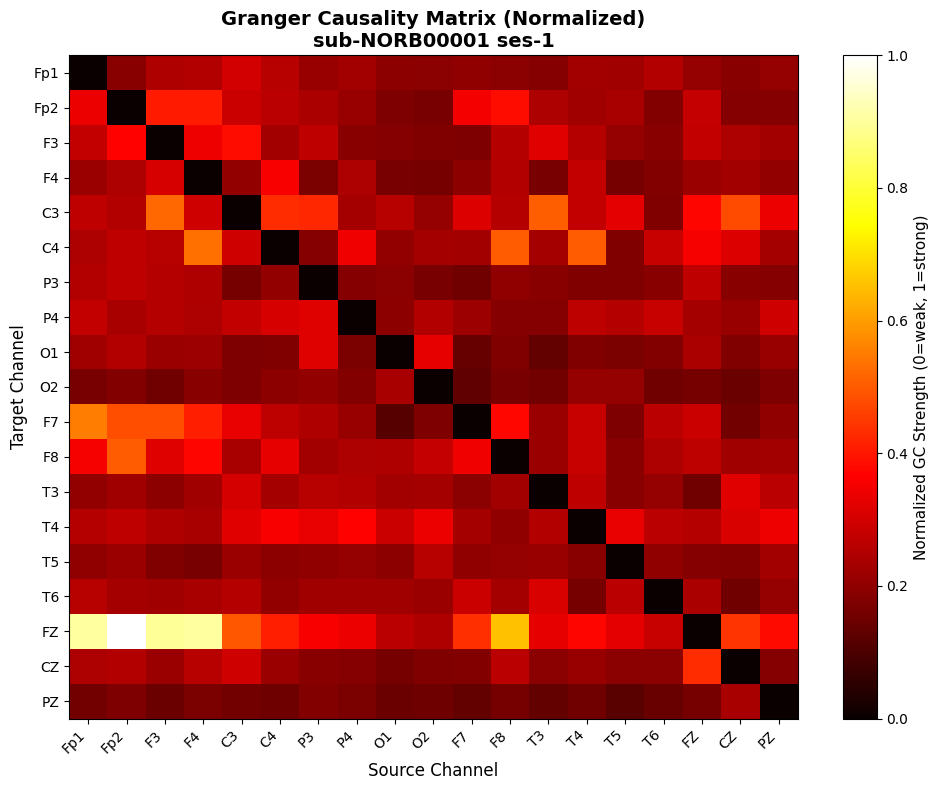

In [66]:
# Create and save heatmap
if 'gc_avg' in locals() and 'raw_filtered' in locals():
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Normalize GC values to 0-1 range
    gc_min = gc_avg.min()
    gc_max = gc_avg.max()
    gc_normalized = (gc_avg - gc_min) / (gc_max - gc_min) if gc_max > gc_min else gc_avg
    
    # Create heatmap
    im = ax.imshow(gc_normalized, cmap='hot', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    
    # Set labels
    channel_names = raw_filtered.ch_names
    ax.set_xticks(range(len(channel_names)))
    ax.set_yticks(range(len(channel_names)))
    ax.set_xticklabels(channel_names, rotation=45, ha='right')
    ax.set_yticklabels(channel_names)
    
    # Labels and title
    ax.set_xlabel('Source Channel', fontsize=12)
    ax.set_ylabel('Target Channel', fontsize=12)
    ax.set_title(f'Granger Causality Matrix (Normalized)\n{subject_id} {session_id}', fontsize=14, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Normalized GC Strength (0=weak, 1=strong)', fontsize=11)
    
    plt.tight_layout()
    
    # Save figure
    output_fig = results_dir / f"{subject_id}_{session_id}_gc_heatmap.png"
    plt.savefig(output_fig, dpi=150, bbox_inches='tight')
    print(f"✓ Saved heatmap to: {output_fig}")
    print(f"  Original range: [{gc_min:.4f}, {gc_max:.4f}]")
    print(f"  Normalized range: [0.0, 1.0]")
    
    plt.show()
else:
    print("Error: GC matrix or channel names not found.")

## Step 5: Repeat for All Subjects

Loop through all 103 subjects and process each session independently.

In [69]:
# Process all subjects - Batch processing
def process_subject(subject_id, dataset_path, results_dir, max_order=20, fixed_order=None):
    """
    Process a single subject: load, preprocess, compute GC, and save results.
    Uses existing helper functions defined above for consistency.
    
    Parameters:
    -----------
    subject_id : str
        Subject ID (e.g., 'sub-NORB00001')
    dataset_path : Path
        Path to dataset directory
    results_dir : Path
        Path to results directory
    max_order : int
        Maximum order for BIC search (ignored if fixed_order is set)
    fixed_order : int or None
        If set, use this order instead of searching
        
    Returns:
    --------
    dict : Processing results and status
    """
    try:
        # Find EDF files using existing function
        subject_path = dataset_path / subject_id
        edf_files = list(subject_path.rglob('*.edf'))
        
        if not edf_files:
            return {'subject': subject_id, 'status': 'no_files', 'sessions': 0}
        
        processed_sessions = []
        
        for edf_file in edf_files:
            try:
                # Load data using existing function
                raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
                
                # Detect bad channels using existing function logic
                bad_channels = detect_bad_channels(raw, flat_threshold=1e-12, noise_threshold=1e-3)
                
                # Remove bad channels
                if bad_channels:
                    raw.drop_channels(bad_channels)
                
                # Skip if too few channels remain
                if len(raw.ch_names) < 2:
                    continue
                
                # Bandpass filter
                raw.filter(l_freq=0.5, h_freq=30.0, fir_design='firwin', verbose=False)
                
                # Segment data using existing function (but without printing)
                sfreq = raw.info['sfreq']
                data_filtered = raw.get_data()
                n_channels, n_samples = data_filtered.shape
                window_length = 10.0
                samples_per_window = int(window_length * sfreq)
                
                segments = []
                start = 0
                while start + samples_per_window <= n_samples:
                    segment = data_filtered[:, start:start + samples_per_window]
                    segments.append(segment)
                    start += samples_per_window
                
                if len(segments) < 1:
                    continue
                
                # Normalize segments using existing function logic
                segments_normalized = normalize_segments(segments)
                
                # Select model order using existing function
                if fixed_order is None:
                    order = select_model_order(segments_normalized[0], max_order=min(max_order, 10))
                else:
                    order = fixed_order
                
                # Fit VAR models using existing function logic
                var_models = []
                for segment in segments_normalized:
                    model = VAR(segment.T)
                    var_models.append(model.fit(order, verbose=False))
                
                # Compute GC matrices using existing function
                gc_matrices = [compute_gc_matrix(model, n_channels) for model in var_models]
                
                # Average across windows
                gc_avg = np.mean(gc_matrices, axis=0)
                
                # Save results
                edf_name = edf_file.stem
                parts = edf_name.split('_')
                session_id = parts[1] if len(parts) > 1 and 'ses' in parts[1] else 'ses-01'
                
                output_file = results_dir / f"{subject_id}_{session_id}_gc_matrix.npy"
                np.save(output_file, gc_avg)
                
                processed_sessions.append({
                    'session': session_id,
                    'channels': n_channels,
                    'windows': len(segments),
                    'order': order,
                    'output': output_file.name
                })
                
            except Exception as e:
                continue
        
        return {
            'subject': subject_id,
            'status': 'success',
            'sessions': len(processed_sessions),
            'details': processed_sessions
        }
        
    except Exception as e:
        return {'subject': subject_id, 'status': 'error', 'error': str(e)}


# Batch process all subjects
# if 'subjects' in locals():
#     print(f"Starting batch processing for {len(subjects)} subjects...")
#     print("=" * 70)
    
#     results_dir = Path('/home/alookaladdoo/DPCN-Project/results')
#     results_dir.mkdir(exist_ok=True)
    
#     all_results = []
#     successful = 0
#     failed = 0
    
#     for idx, subject in enumerate(subjects, 1):
#         print(f"\n[{idx}/{len(subjects)}] Processing {subject}...", end=' ')
        
#         result = process_subject(subject, dataset_path, results_dir, fixed_order=2)
#         all_results.append(result)
        
#         if result['status'] == 'success' and result['sessions'] > 0:
#             successful += 1
#             print(f"✓ ({result['sessions']} session(s))")
#         elif result['status'] == 'no_files':
#             print("⊘ No EDF files")
#         else:
#             failed += 1
#             print("✗ Failed")
    
#     print("\n" + "=" * 70)
#     print(f"Batch processing complete!")
#     print(f"  Successful: {successful}/{len(subjects)}")
#     print(f"  Failed/No files: {failed + (len(subjects) - successful - failed)}/{len(subjects)}")
#     print(f"  Output directory: {results_dir}")
# else:
#     print("Error: Subjects list not found.")

In [70]:
# Parallel batch processing - MUCH FASTER!
from joblib import Parallel, delayed
import multiprocessing

if 'subjects' in locals():
    print(f"Starting PARALLEL batch processing for {len(subjects)} subjects...")
    n_cores = multiprocessing.cpu_count()
    print(f"Using {n_cores} CPU cores")
    print("=" * 70)
    
    results_dir = Path('/home/alookaladdoo/DPCN-Project/results')
    results_dir.mkdir(exist_ok=True)
    
    # Process subjects in parallel
    all_results = Parallel(n_jobs=n_cores)(
        delayed(process_subject)(subject, dataset_path, results_dir, fixed_order=2)
        for subject in subjects
    )
    
    # Count results
    successful = sum(1 for r in all_results if r['status'] == 'success' and r['sessions'] > 0)
    no_files = sum(1 for r in all_results if r['status'] == 'no_files')
    failed = len(all_results) - successful - no_files
    
    print("\n" + "=" * 70)
    print(f"Parallel batch processing complete!")
    print(f"  Successful: {successful}/{len(subjects)}")
    print(f"  No files: {no_files}/{len(subjects)}")
    print(f"  Failed: {failed}/{len(subjects)}")
    print(f"  Output directory: {results_dir}")
    
    # Show detailed results for failed subjects
    if failed > 0:
        print(f"\nFailed subjects:")
        for r in all_results:
            if r['status'] == 'error':
                print(f"  - {r['subject']}")
else:
    print("Error: Subjects list not found.")

Starting PARALLEL batch processing for 103 subjects...
Using 16 CPU cores

Channel Quality Check:
------------------------------------------------------------
  Fp1             | std=5.56e-05 | mean=2.68e-06 | OK   
  Fp2             | std=5.19e-05 | mean=-1.40e-06 | OK   
  F3              | std=5.40e-05 | mean=-3.94e-07 | OK   
  F4              | std=6.30e-05 | mean=6.04e-06 | OK   
  C3              | std=5.30e-05 | mean=2.97e-06 | OK   
  C4              | std=6.23e-05 | mean=3.52e-07 | OK   
  P3              | std=4.96e-05 | mean=-3.86e-06 | OK   
  P4              | std=6.01e-05 | mean=3.31e-06 | OK   
  O1              | std=4.84e-05 | mean=1.35e-06 | OK   
  O2              | std=6.00e-05 | mean=-6.52e-07 | OK   
  F7              | std=5.46e-05 | mean=-9.02e-07 | OK   
  F8              | std=1.04e-04 | mean=5.25e-07 | OK   
  T3              | std=5.09e-05 | mean=-2.05e-06 | OK   
  T4              | std=5.15e-05 | mean=2.62e-06 | OK   
  T5              | std=5.24e-05 | me

/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.



Channel Quality Check:
------------------------------------------------------------
  Fp1             | std=2.72e-05 | mean=6.64e-06 | OK   
  Fp2             | std=2.66e-05 | mean=5.58e-06 | OK   
  F3              | std=2.90e-05 | mean=6.02e-06 | OK   
  F4              | std=2.84e-05 | mean=5.51e-06 | OK   
  C3              | std=2.91e-05 | mean=6.54e-06 | OK   
  C4              | std=3.29e-05 | mean=5.98e-06 | OK   
  P3              | std=2.91e-05 | mean=6.04e-06 | OK   
  P4              | std=2.76e-05 | mean=7.27e-06 | OK   
  O1              | std=2.84e-05 | mean=4.68e-06 | OK   
  O2              | std=2.77e-05 | mean=6.19e-06 | OK   
  F7              | std=2.61e-05 | mean=5.18e-06 | OK   
  F8              | std=2.63e-05 | mean=6.60e-06 | OK   
  T3              | std=2.56e-05 | mean=5.59e-06 | OK   
  T4              | std=2.59e-05 | mean=6.81e-06 | OK   
  T5              | std=2.79e-05 | mean=4.97e-06 | OK   
  T6              | std=2.65e-05 | mean=5.69e-06 | OK   
  F

/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.



Channel Quality Check:
------------------------------------------------------------
  Fp1             | std=2.81e-05 | mean=7.39e-06 | OK   
  Fp2             | std=3.05e-05 | mean=6.16e-06 | OK   
  F3              | std=3.21e-05 | mean=6.82e-06 | OK   
  F4              | std=3.30e-05 | mean=6.15e-06 | OK   
  C3              | std=3.35e-05 | mean=6.99e-06 | OK   
  C4              | std=3.27e-05 | mean=6.65e-06 | OK   
  P3              | std=3.22e-05 | mean=6.49e-06 | OK   
  P4              | std=3.13e-05 | mean=6.92e-06 | OK   
  O1              | std=3.10e-05 | mean=5.76e-06 | OK   
  O2              | std=3.40e-05 | mean=7.01e-06 | OK   
  F7              | std=2.48e-05 | mean=5.78e-06 | OK   
  F8              | std=2.84e-05 | mean=7.11e-06 | OK   
  T3              | std=2.33e-05 | mean=5.77e-06 | OK   
  T4              | std=2.60e-05 | mean=7.46e-06 | OK   
  T5              | std=2.90e-05 | mean=5.88e-06 | OK   
  T6              | std=2.87e-05 | mean=6.37e-06 | OK   
  F

...


Channel Quality Check:
------------------------------------------------------------
  Fp1             | std=3.55e-05 | mean=7.71e-06 | OK   
  Fp2             | std=3.49e-05 | mean=7.09e-06 | OK   
  F3              | std=4.50e-05 | mean=7.34e-06 | OK   
  F4              | std=4.46e-05 | mean=6.74e-06 | OK   
  C3              | std=4.67e-05 | mean=7.61e-06 | OK   
  C4              | std=4.47e-05 | mean=7.35e-06 | OK   
  P3              | std=4.96e-05 | mean=7.15e-06 | OK   
  P4              | std=4.82e-05 | mean=7.08e-06 | OK   
  O1              | std=5.78e-05 | mean=6.16e-06 | OK   
  O2              | std=5.80e-05 | mean=7.18e-06 | OK   
  F7              | std=3.51e-05 | mean=7.14e-06 | OK   
  F8              | std=3.79e-05 | mean=6.87e-06 | OK   
  T3              | std=3.19e-05 | mean=7.61e-06 | OK   
  T4              | std=3.15e-05 | mean=7.22e-06 | OK   
  T5              | std=4.66e-05 | mean=6.16e-06 | OK   
  T6              | std=4.11e-05 | mean=7.20e-06 | OK   
  F

/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 30.0, setting values to 0 and Nyquist.



Channel Quality Check:
------------------------------------------------------------
  Fp1             | std=2.60e-05 | mean=7.39e-06 | OK   
  Fp2             | std=2.69e-05 | mean=6.91e-06 | OK   
  F3              | std=3.14e-05 | mean=7.15e-06 | OK   
  F4              | std=2.99e-05 | mean=6.75e-06 | OK   
  C3              | std=3.25e-05 | mean=7.65e-06 | OK   
  C4              | std=3.12e-05 | mean=7.04e-06 | OK   
  P3              | std=3.15e-05 | mean=7.03e-06 | OK   
  P4              | std=2.99e-05 | mean=6.86e-06 | OK   
  O1              | std=3.75e-05 | mean=5.80e-06 | OK   
  O2              | std=3.68e-05 | mean=6.72e-06 | OK   
  F7              | std=2.34e-05 | mean=6.94e-06 | OK   
  F8              | std=2.73e-05 | mean=6.65e-06 | OK   
  T3              | std=2.47e-05 | mean=7.53e-06 | OK   
  T4              | std=2.35e-05 | mean=6.94e-06 | OK   
  T5              | std=3.12e-05 | mean=5.89e-06 | OK   
  T6              | std=2.80e-05 | mean=6.86e-06 | OK   
  F

/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
/tmp/ipykernel_6624/1169001934.py:37: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 30.0, setting values to 0 and Nyquist.



Channel Quality Check:
------------------------------------------------------------
  Fp1             | std=2.60e-05 | mean=7.87e-06 | OK   
  Fp2             | std=2.53e-05 | mean=7.39e-06 | OK   
  F3              | std=3.58e-05 | mean=7.50e-06 | OK   
  F4              | std=3.13e-05 | mean=7.18e-06 | OK   
  C3              | std=3.53e-05 | mean=7.71e-06 | OK   
  C4              | std=3.36e-05 | mean=7.46e-06 | OK   
  P3              | std=3.72e-05 | mean=7.31e-06 | OK   
  P4              | std=3.39e-05 | mean=7.17e-06 | OK   
  O1              | std=3.92e-05 | mean=6.20e-06 | OK   
  O2              | std=4.28e-05 | mean=7.19e-06 | OK   
  F7              | std=2.83e-05 | mean=7.34e-06 | OK   
  F8              | std=2.48e-05 | mean=7.08e-06 | OK   
  T3              | std=3.04e-05 | mean=7.80e-06 | OK   
  T4              | std=2.27e-05 | mean=7.49e-06 | OK   
  T5              | std=3.64e-05 | mean=6.14e-06 | OK   
  T6              | std=3.11e-05 | mean=7.41e-06 | OK   
  F

## Step 6: Group Analysis

Load all GC matrices, compute group average, and create group heatmap.

In [71]:
# Load all GC matrices from results directory
results_dir = Path('/home/alookaladdoo/DPCN-Project/results')

if results_dir.exists():
    # Find all .npy files
    gc_files = sorted(list(results_dir.glob('*_gc_matrix.npy')))
    
    print(f"Found {len(gc_files)} GC matrix files in results directory")
    
    if len(gc_files) > 0:
        # Load all matrices
        all_gc_matrices = []
        valid_files = []
        
        print("\nLoading GC matrices...")
        for idx, gc_file in enumerate(gc_files, 1):
            try:
                gc_matrix = np.load(gc_file)
                all_gc_matrices.append(gc_matrix)
                valid_files.append(gc_file.stem)
                
                # Progress indicator
                if idx % 10 == 0 or idx == len(gc_files):
                    print(f"  Loaded: {idx}/{len(gc_files)}", end='\r')
            except Exception as e:
                print(f"\n  Warning: Could not load {gc_file.name}: {e}")
                continue
        
        print(f"\n✓ Successfully loaded {len(all_gc_matrices)} matrices")
        
        # Check if all matrices have same shape
        shapes = [m.shape for m in all_gc_matrices]
        unique_shapes = set(shapes)
        
        if len(unique_shapes) > 1:
            print(f"\n⚠ Warning: Found matrices with different shapes: {unique_shapes}")
            print("  Grouping by shape for separate analysis...")
            
            # Group by shape
            shape_groups = {}
            for matrix, filename in zip(all_gc_matrices, valid_files):
                shape = matrix.shape
                if shape not in shape_groups:
                    shape_groups[shape] = {'matrices': [], 'files': []}
                shape_groups[shape]['matrices'].append(matrix)
                shape_groups[shape]['files'].append(filename)
            
            # Analyze largest group
            largest_shape = max(shape_groups.keys(), key=lambda s: len(shape_groups[s]['matrices']))
            print(f"\n  Using largest group: {largest_shape} ({len(shape_groups[largest_shape]['matrices'])} subjects)")
            
            all_gc_matrices = shape_groups[largest_shape]['matrices']
            valid_files = shape_groups[largest_shape]['files']
        
        print(f"\n✓ Analysis set: {len(all_gc_matrices)} matrices with shape {all_gc_matrices[0].shape}")
        
    else:
        print("\n⚠ No GC matrix files found. Please run Step 5 first.")
        all_gc_matrices = None
else:
    print(f"\n⚠ Results directory not found: {results_dir}")
    print("  Please run Step 5 first to process subjects.")
    all_gc_matrices = None

Found 130 GC matrix files in results directory

Loading GC matrices...
  Loaded: 130/130
✓ Successfully loaded 130 matrices

⚠ Warning: Found matrices with different shapes: {(19, 19), (22, 22), (2, 2)}
  Grouping by shape for separate analysis...

  Using largest group: (19, 19) (106 subjects)

✓ Analysis set: 106 matrices with shape (19, 19)


In [72]:
# Compute group average GC matrix
if all_gc_matrices is not None and len(all_gc_matrices) > 0:
    # Stack all matrices and compute mean
    gc_group_avg = np.mean(all_gc_matrices, axis=0)
    gc_group_std = np.std(all_gc_matrices, axis=0)
    
    print(f"Group Average GC Matrix:")
    print(f"  Shape: {gc_group_avg.shape}")
    print(f"  Mean GC value: {gc_group_avg.mean():.4f}")
    print(f"  Std GC value: {gc_group_avg.std():.4f}")
    print(f"  Min GC value: {gc_group_avg.min():.4f}")
    print(f"  Max GC value: {gc_group_avg.max():.4f}")
    print(f"  Number of subjects: {len(all_gc_matrices)}")
    
    # Save group average matrix
    output_file = results_dir / 'group_average_gc.npy'
    np.save(output_file, gc_group_avg)
    print(f"\n✓ Saved group average to: {output_file}")
    
    # Save group std matrix
    output_std_file = results_dir / 'group_std_gc.npy'
    np.save(output_std_file, gc_group_std)
    print(f"✓ Saved group std to: {output_std_file}")
else:
    print("Error: No GC matrices loaded.")

Group Average GC Matrix:
  Shape: (19, 19)
  Mean GC value: 5.8701
  Std GC value: 2.7069
  Min GC value: 0.0000
  Max GC value: 16.1317
  Number of subjects: 106

✓ Saved group average to: /home/alookaladdoo/DPCN-Project/results/group_average_gc.npy
✓ Saved group std to: /home/alookaladdoo/DPCN-Project/results/group_std_gc.npy



✓ Saved group heatmap to: /home/alookaladdoo/DPCN-Project/results/group_average_gc_heatmap.png
  Original range: [0.0000, 16.1317]
  Normalized range: [0.0, 1.0]


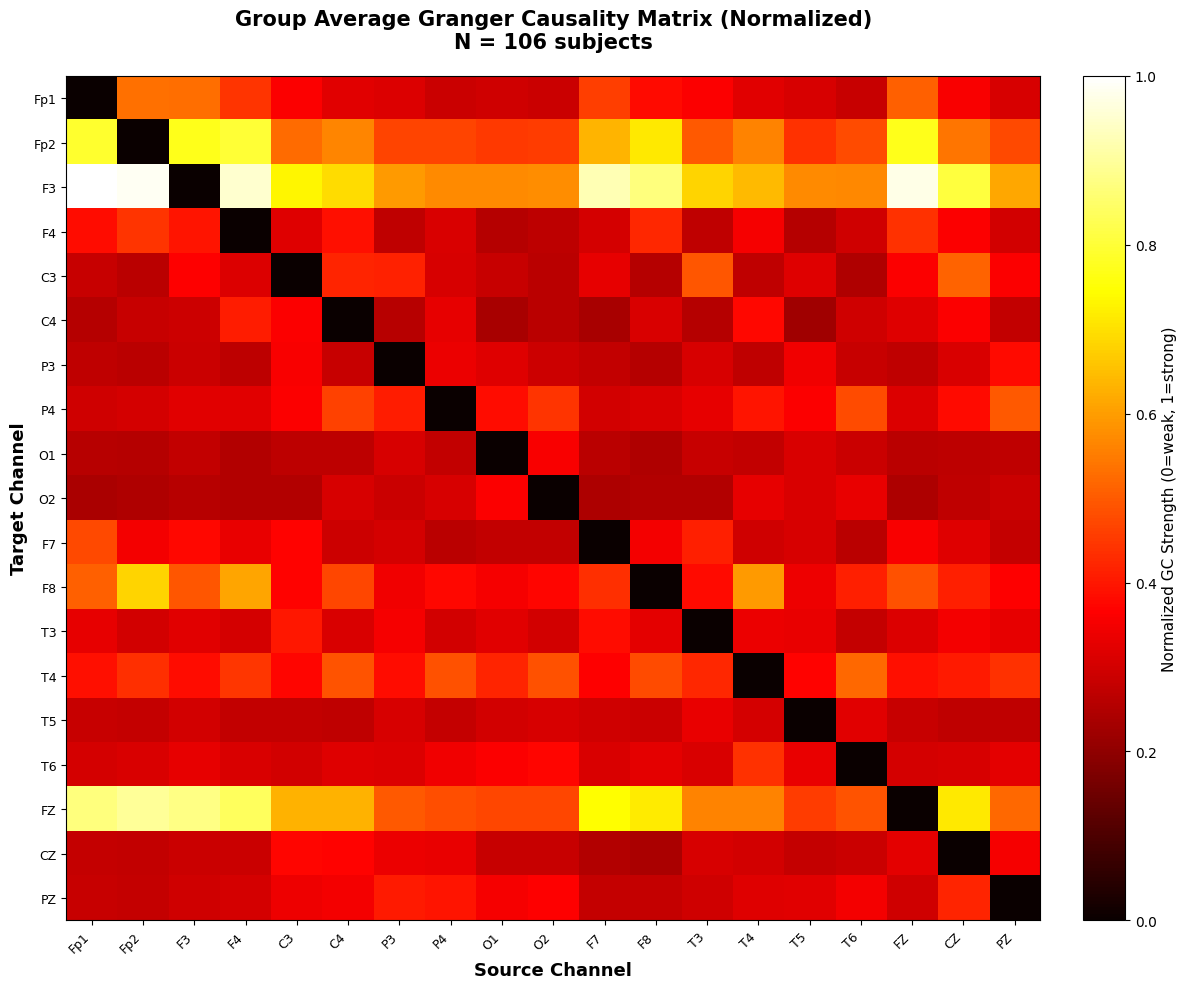


✓ Group analysis complete!
  Analyzed 106 subjects
  Files saved in: /home/alookaladdoo/DPCN-Project/results


In [73]:
# Create group heatmap
if 'gc_group_avg' in locals():
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Normalize GC values to 0-1 range
    gc_min = gc_group_avg.min()
    gc_max = gc_group_avg.max()
    gc_normalized = (gc_group_avg - gc_min) / (gc_max - gc_min) if gc_max > gc_min else gc_group_avg
    
    # Create heatmap
    im = ax.imshow(gc_normalized, cmap='hot', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    
    # Set labels (use channel names from first loaded matrix if available)
    n_channels = gc_group_avg.shape[0]
    
    # Try to get channel names from a sample file
    try:
        # Load a sample EDF to get channel names
        sample_subject = subjects[0] if 'subjects' in locals() else None
        if sample_subject:
            sample_files = list((dataset_path / sample_subject).rglob('*.edf'))
            if sample_files:
                sample_raw = mne.io.read_raw_edf(sample_files[0], preload=False, verbose=False)
                # Remove bad channels
                sample_bad = [ch for ch in sample_raw.ch_names if ch.upper() in ['PG1', 'PG2', 'REF', 'GND', 'GROUND']]
                channel_names = [ch for ch in sample_raw.ch_names if ch not in sample_bad][:n_channels]
            else:
                channel_names = [f'Ch{i+1}' for i in range(n_channels)]
        else:
            channel_names = [f'Ch{i+1}' for i in range(n_channels)]
    except:
        channel_names = [f'Ch{i+1}' for i in range(n_channels)]
    
    # Ensure we have the right number of channel names
    if len(channel_names) != n_channels:
        channel_names = [f'Ch{i+1}' for i in range(n_channels)]
    
    ax.set_xticks(range(n_channels))
    ax.set_yticks(range(n_channels))
    ax.set_xticklabels(channel_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(channel_names, fontsize=9)
    
    # Labels and title
    ax.set_xlabel('Source Channel', fontsize=13, fontweight='bold')
    ax.set_ylabel('Target Channel', fontsize=13, fontweight='bold')
    ax.set_title(f'Group Average Granger Causality Matrix (Normalized)\nN = {len(all_gc_matrices)} subjects', 
                 fontsize=15, fontweight='bold', pad=20)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Normalized GC Strength (0=weak, 1=strong)', fontsize=11)
    
    plt.tight_layout()
    
    # Save figure
    output_fig = results_dir / 'group_average_gc_heatmap.png'
    plt.savefig(output_fig, dpi=200, bbox_inches='tight')
    print(f"\n✓ Saved group heatmap to: {output_fig}")
    print(f"  Original range: [{gc_min:.4f}, {gc_max:.4f}]")
    print(f"  Normalized range: [0.0, 1.0]")
    
    plt.show()
    
    print(f"\n✓ Group analysis complete!")
    print(f"  Analyzed {len(all_gc_matrices)} subjects")
    print(f"  Files saved in: {results_dir}")
else:
    print("Error: Group average GC matrix not computed.")

In [14]:
# Summary statistics for group analysis
if 'gc_group_avg' in locals() and 'gc_group_std' in locals():
    print("=" * 70)
    print("GROUP ANALYSIS SUMMARY")
    print("=" * 70)
    
    print(f"\n Dataset Statistics:")
    print(f"  Total subjects analyzed: {len(all_gc_matrices)}")
    print(f"  Matrix dimensions: {gc_group_avg.shape}")
    print(f"  Number of connections: {gc_group_avg.shape[0] * (gc_group_avg.shape[1] - 1)}")
    
    print(f"\n Group Average GC Values:")
    print(f"  Mean: {gc_group_avg.mean():.4f}")
    print(f"  Median: {np.median(gc_group_avg):.4f}")
    print(f"  Std: {gc_group_avg.std():.4f}")
    print(f"  Min: {gc_group_avg.min():.4f}")
    print(f"  Max: {gc_group_avg.max():.4f}")
    
    print(f"\n Group Variability (Std across subjects):")
    print(f"  Mean variability: {gc_group_std.mean():.4f}")
    print(f"  Median variability: {np.median(gc_group_std):.4f}")
    print(f"  Min variability: {gc_group_std.min():.4f}")
    print(f"  Max variability: {gc_group_std.max():.4f}")
    
    # Find strongest connections (excluding diagonal)
    n_ch = gc_group_avg.shape[0]
    mask = ~np.eye(n_ch, dtype=bool)
    flat_gc = gc_group_avg[mask]
    flat_indices = np.argsort(flat_gc)[-5:][::-1]  # Top 5
    
    print(f"\n Top 5 Strongest Group Connections:")
    row_indices, col_indices = np.where(mask)
    for rank, idx in enumerate(flat_indices, 1):
        i, j = row_indices[idx], col_indices[idx]
        gc_value = gc_group_avg[i, j]
        if len(channel_names) > max(i, j):
            print(f"  {rank}. {channel_names[j]} → {channel_names[i]}: {gc_value:.4f}")
        else:
            print(f"  {rank}. Ch{j+1} → Ch{i+1}: {gc_value:.4f}")
    
    print(f"\n Output Files:")
    print(f"  - group_average_gc.npy")
    print(f"  - group_std_gc.npy")
    print(f"  - group_average_gc_heatmap.png")
    
    print("\n" + "=" * 70)
    print("=" * 70)
else:
    print("Error: Group analysis not completed.")

Error: Group analysis not completed.
